# Bayesian UCB

## Getting ready dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Tuple
np.random.seed(4014)

In [3]:
DATA_PATH = 'synthetic_spf_scam_cases_1H2025.csv'

df = pd.read_csv(DATA_PATH)
df.head()

,case_id,age_group,scam_type,contact_method,source_platform,requires_user_action,payment_method,urgency_level,loss_bucket,transaction_amount,is_scam
0,1,30-49,Job,Classified Ads,Classifieds,1,Card,Medium,2k-5k,3721.57,1
1,2,20-29,Phishing,Classified Ads,Classifieds,1,E-wallet,Medium,2k-5k,2168.36,1
2,3,20-29,Job,Phone Call,Phone,1,E-wallet,High,5k-10k,5811.74,1
3,4,30-49,Phishing,Social Media,Facebook,1,Card,Medium,<2k,187.44,1
4,5,<20,Job,Messaging,WhatsApp,1,E-wallet,Medium,10k-50k,12426.74,1


## Feature Engineering

In [5]:
categorical_features = [
    'age_group',
    'scam_type',
    'source_platform',
    'payment_method',
    'urgency_level',
    'loss_bucket'
]

feature_df = pd.get_dummies(df[categorical_features], drop_first=False)

feature_df['requires_user_action'] = df['requires_user_action'].astype(float)
feature_df['log_amount'] = np.log1p(df['transaction_amount'])

feature_matrix = feature_df.to_numpy(dtype=float)
feature_columns = feature_df.columns.tolist()

print(f'Feature matrix shape: {feature_matrix.shape}')
feature_df.head()

Feature matrix shape: (19665, 52)


,age_group_20-29,age_group_30-49,age_group_50-64,age_group_65+,age_group_<20,scam_type_E-commerce,scam_type_Fake Friend Call,scam_type_Government Impersonation,scam_type_Insurance Services,scam_type_Internet Love,...,urgency_level_Low,urgency_level_Medium,loss_bucket_100k+,loss_bucket_10k-50k,loss_bucket_2k-5k,loss_bucket_50k-100k,loss_bucket_5k-10k,loss_bucket_<2k,requires_user_action,log_amount
0,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1.0,8.222170
1,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1.0,7.682187
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1.0,8.667807
3,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1.0,5.238780
4,0,0,0,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1.0,9.427686


## Arm declaration

In [6]:
class InterventionArm:
    def __init__(self, arm_id, name, friction, effectiveness):
        self.arm_id = arm_id
        self.name = name
        self.friction = friction
        self.effectiveness = effectiveness


ARMS = [
    InterventionArm(
        arm_id=0,
        name='Self-guided checklist',
        friction=0.05,
        effectiveness=0.20,
    ),
    InterventionArm(
        arm_id=1,
        name='Digital footprint scan',
        friction=0.15,
        effectiveness=0.50,
    ),
    InterventionArm(
        arm_id=2,
        name='Redirect to official channels',
        friction=0.30,
        effectiveness=0.70,
    ),
    InterventionArm(
        arm_id=3,
        name='Schedule transaction',
        friction=0.50,
        effectiveness=0.85,
    ),
    InterventionArm(
        arm_id=4,
        name='Mandatory bank consultation',
        friction=0.80,
        effectiveness=0.95,
    ),
]

n_arms = len(ARMS)
arm_names = [arm.name for arm in ARMS]
context_dim = feature_matrix.shape[1]

## Bayesian UCB

In [19]:
class BayesianUCB:
    """
    Bayesian UCB for contextual linear rewards.

    Posterior per arm:
        theta_a ~ N(mu_a, v^2 * B_a^{-1})

    Selection rule:
        choose arm a maximising
            x^T mu_a + beta * sqrt(x^T (v^2 * B_a^{-1}) x)
    """

    def __init__(self, n_arms: int, context_dim: int, v: float = 1.0, beta: float = 1.96):
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.v = v
        self.beta = beta
        self._reset()

    def _reset(self):
        d = self.context_dim
        self.B = [np.eye(d) for _ in range(self.n_arms)]      # precision-like matrix
        self.f = [np.zeros(d) for _ in range(self.n_arms)]    # sufficient statistic
        self.mu = [np.zeros(d) for _ in range(self.n_arms)]   # posterior mean
        self.t = 0
        self.history = []

    def update(self, arm: int, context: np.ndarray, reward: float):
        x = np.asarray(context, dtype=float)
        self.B[arm] += np.outer(x, x)
        self.f[arm] += x * reward
        self.mu[arm] = np.linalg.solve(self.B[arm], self.f[arm])

    def posterior_cov(self, arm: int) -> np.ndarray:
        return self.v**2 * np.linalg.inv(self.B[arm])

    def posterior_mean(self, arm: int) -> np.ndarray:
        return self.mu[arm].copy()

    def score_arm(self, arm: int, context: np.ndarray) -> float:
        x = np.asarray(context, dtype=float)
        mu_a = self.mu[arm]
        cov_a = self.posterior_cov(arm)

        mean_reward = x @ mu_a
        std_reward = np.sqrt(np.clip(x @ cov_a @ x, 0.0, None))

        return float(mean_reward + self.beta * std_reward)

    def select_arm(self, context: np.ndarray) -> int:
        scores = [self.score_arm(a, context) for a in range(self.n_arms)]
        return int(np.argmax(scores))

    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        self.t += 1
        arm = self.select_arm(context)
        reward = reward_fn(arm, context)
        self.update(arm, context, reward)

        info = {
            't': self.t,
            'arm': arm,
            'reward': reward,
            'scores': [self.score_arm(a, context) for a in range(self.n_arms)]
        }
        self.history.append(info)
        return info

### Prepare Simulation Environment

In [20]:
class Environment:
    def __init__(self, feature_matrix: np.ndarray, arms: list, df: pd.DataFrame):
        self.feature_matrix = feature_matrix
        self.arms = arms
        self.df = df
        self.n_arms = len(arms)
        self.context_dim = feature_matrix.shape[1]

        # Hidden linear component for realism
        self.true_theta = np.random.randn(self.n_arms, self.context_dim) * 0.3
        for arm_id in range(self.n_arms):
            self.true_theta[arm_id] *= arms[arm_id].effectiveness

    def compute_reward(
        self,
        arm_id: int,
        context: np.ndarray,
        scam_prob: float,
        transaction_amount: float,
        urgency: float
    ) -> float:
        arm = self.arms[arm_id]

        linear_term = context @ self.true_theta[arm_id]

        financial_benefit = scam_prob * (transaction_amount / 10000.0) * arm.effectiveness
        friction_penalty = (1.0 - scam_prob) * arm.friction * urgency

        reward = financial_benefit - friction_penalty

        return float((0.5 * reward) + (0.5 * linear_term) + np.random.normal(0, 0.1))

    def sample_context(self) -> Tuple[np.ndarray, float, float, float]:
        idx = np.random.randint(0, len(self.feature_matrix))
        context = self.feature_matrix[idx].copy()

        sample = self.df.iloc[idx]
        scam_prob = float(sample['is_scam'])
        amount = float(sample['transaction_amount'])

        urgency_map = {'Low': 1, 'Medium': 2, 'High': 3}
        urgency = urgency_map.get(sample['urgency_level'], 2) / 3.0

        return context, scam_prob, amount, urgency

    def expected_reward(self, arm_id: int, context: np.ndarray, scam_prob: float, amount: float, urgency: float) -> float:
        """
        Noise-free expected reward.
        Use this for a cleaner regret calculation.
        """
        arm = self.arms[arm_id]
        linear_term = context @ self.true_theta[arm_id]
        financial_benefit = scam_prob * (amount / 10000.0) * arm.effectiveness
        friction_penalty = (1.0 - scam_prob) * arm.friction * urgency
        reward = financial_benefit - friction_penalty
        return float((0.5 * reward) + (0.5 * linear_term))

    def optimal_arm(self, context: np.ndarray, scam_prob: float, amount: float, urgency: float) -> int:
        rewards = [
            self.expected_reward(a, context, scam_prob, amount, urgency)
            for a in range(self.n_arms)
        ]
        return int(np.argmax(rewards))

    def optimal_reward(self, context: np.ndarray, scam_prob: float, amount: float, urgency: float) -> float:
        arm = self.optimal_arm(context, scam_prob, amount, urgency)
        return self.expected_reward(arm, context, scam_prob, amount, urgency)

# Simulation
## Prepare simulation

In [10]:
env = Environment(feature_matrix, ARMS, df)
agent = BayesianUCB(
    n_arms=len(ARMS),
    context_dim=feature_matrix.shape[1],
    v=1.0,
    beta=1.96
)

In [13]:
N_SIMULATIONS = 100
N_TIMESTEPS = 1000

all_rewards = []
all_regrets = []
all_arms = []
all_arm_counts = np.zeros(len(ARMS))

for sim in range(N_SIMULATIONS):
    agent._reset()

    sim_rewards = []
    sim_regrets = []
    sim_arms = []

    for t in range(N_TIMESTEPS):
        context, scam_prob, amount, urgency = env.sample_context()

        def reward_fn(arm, ctx):
            return env.compute_reward(arm, ctx, scam_prob, amount, urgency)

        info = agent.act_and_learn(context, reward_fn)

        optimal_reward = env.optimal_reward(context, scam_prob, amount, urgency)
        regret = optimal_reward - env.expected_reward(info['arm'], context, scam_prob, amount, urgency)

        sim_rewards.append(info['reward'])
        sim_regrets.append(regret)
        sim_arms.append(info['arm'])

    all_rewards.append(np.array(sim_rewards))
    all_regrets.append(np.array(sim_regrets))
    all_arms.append(np.array(sim_arms))
    all_arm_counts += np.bincount(sim_arms, minlength=len(ARMS))

# Aggregate the results

In [14]:
rewards_array = np.array(all_rewards)
regrets_array = np.array(all_regrets)

rewards_mean = rewards_array.mean(axis=0)
regrets_mean = regrets_array.mean(axis=0)

rewards_std = rewards_array.std(axis=0)
regrets_std = regrets_array.std(axis=0)

print(f'Mean final reward: {rewards_mean[-1]:.4f}')
print(f'Mean cumulative regret: {regrets_mean.cumsum()[-1]:.4f}')

Mean final reward: 1.8330
Mean cumulative regret: 328.6224


## Average reward per time step

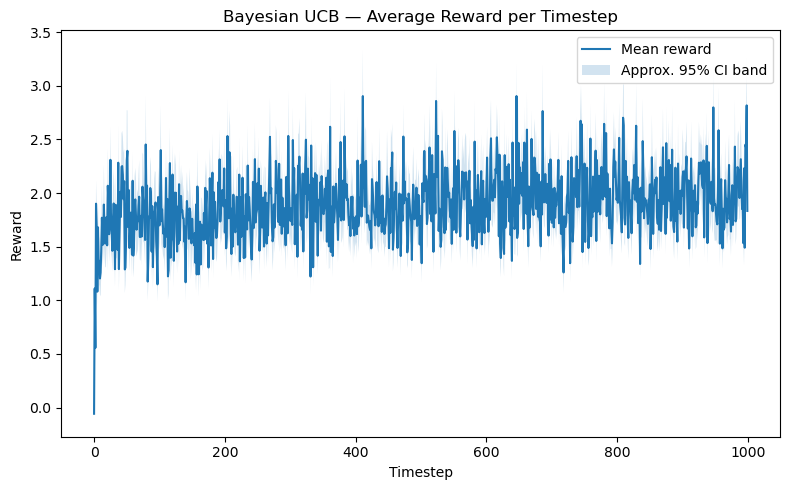

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(rewards_mean, linewidth=1.5, label='Mean reward')
plt.fill_between(
    np.arange(len(rewards_mean)),
    rewards_mean - rewards_std / np.sqrt(N_SIMULATIONS),
    rewards_mean + rewards_std / np.sqrt(N_SIMULATIONS),
    alpha=0.2,
    label='Approx. 95% CI band'
)
plt.title('Bayesian UCB — Average Reward per Timestep')
plt.xlabel('Timestep')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.show()

## Average regret per timestep

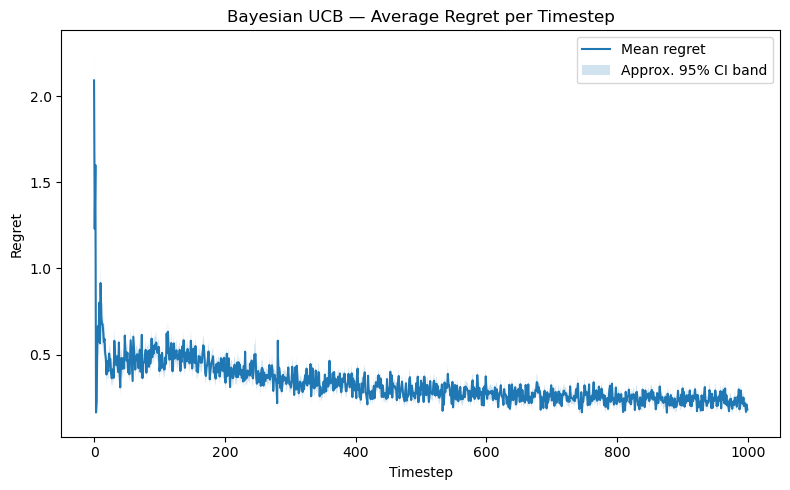

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(regrets_mean, linewidth=1.5, label='Mean regret')
plt.fill_between(
    np.arange(len(regrets_mean)),
    regrets_mean - regrets_std / np.sqrt(N_SIMULATIONS),
    regrets_mean + regrets_std / np.sqrt(N_SIMULATIONS),
    alpha=0.2,
    label='Approx. 95% CI band'
)
plt.title('Bayesian UCB — Average Regret per Timestep')
plt.xlabel('Timestep')
plt.ylabel('Regret')
plt.legend()
plt.tight_layout()
plt.show()

## Cumulative regret

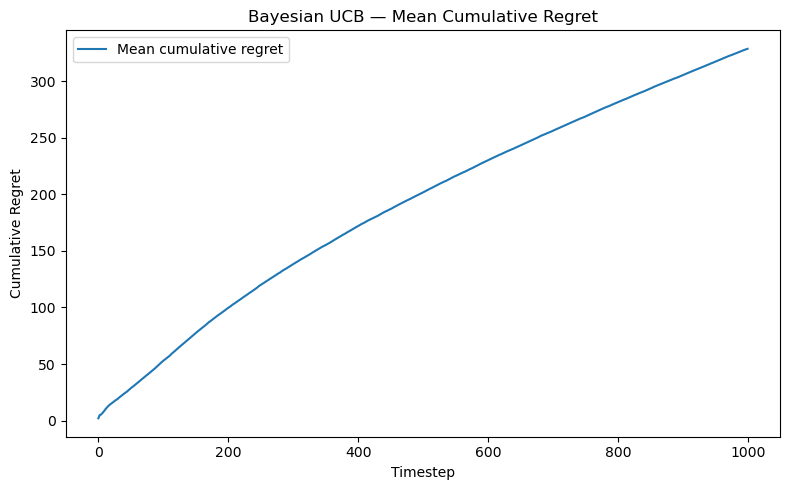

In [17]:
cumulative_regret_mean = regrets_array.cumsum(axis=1).mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_regret_mean, linewidth=1.5, label='Mean cumulative regret')
plt.title('Bayesian UCB — Mean Cumulative Regret')
plt.xlabel('Timestep')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.tight_layout()
plt.show()

## Arm selection frequency

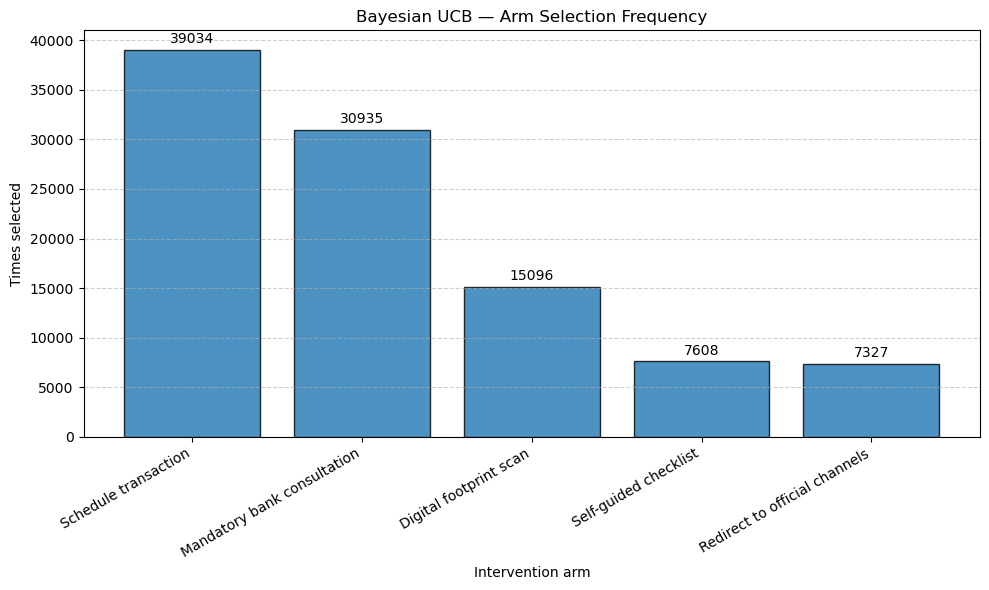

In [18]:
sorted_idx = np.argsort(all_arm_counts)[::-1]
sorted_names = [arm_names[i] for i in sorted_idx]
sorted_counts = all_arm_counts[sorted_idx]

plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_names, sorted_counts, alpha=0.8, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + sorted_counts.max() * 0.01,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Bayesian UCB — Arm Selection Frequency')
plt.ylabel('Times selected')
plt.xlabel('Intervention arm')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()